<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/assingments/assingment_2/MINE_4210_ADL_202620_T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)


# **Taller 2: Clasificación con CNN y transfer learning**

### **Contexto y Objetivos**

Las enfermedades de la yuca pueden ocasionar pérdidas importantes si no se detectan oportunamente. Aplicaciones como PlantVillage o Nuru utilizan modelos de deep learning para diagnosticar estas enfermedades a partir de fotografías tomadas con dispositivos móviles.

En este taller abordarán una versión simplificada de este problema mediante la clasificación de imágenes de hojas de yuca en cinco categorías (cuatro enfermedades y hoja sana), con el propósito de analizar cómo influye la cantidad de datos disponibles en el desempeño de diferentes estrategias de clasificación.

**Conjunto de datos:** Se utilizará el dataset Cassava, disponible en tensorflow_datasets:
```python
import tensorflow_datasets as tfds
ds_train, ds_val, ds_test = tfds.load(
   'cassava',
   split=['train', 'validation', 'test'],
   as_supervised=True
)
```

**Modelo para construir:** El objetivo es construir y comparar los siguientes enfoques.

- Modelo 1. Arquitectura:
  - 3 bloques Conv2D + ReLU + MaxPooling, con 32, 64 y 128 filtros, respectivamente, y kernel 3×3.
  - GlobalAveragePooling2D.
  - Dense(128, activation='relu') + Dropout(0.5).
  - Dense(5, activation='softmax').
- Modelo 2 (con transfer learning): Seleccionar uno de los siguientes backbones preentrenados en ImageNet.
  - MobileNetV2
  - EfficientNetB0

Con base en estos dos enfoques, entrenar los modelos que se indican a continuación, con diferentes tamaños de datos:

| Cantidad de datos | Modelo 1 | Modelo 2 |
|-|-|-|
| 150 imágenes | CNN desde cero | Transfer Learning |
| 800 imágenes | CNN desde cero | Transfer Learning |
| 2500 imágenes | CNN desde cero | Transfer Learning |

Utilicen en todos los casos los mismos conjuntos de validación y test. La configuración para todos los experimentos es:

- Tamaño de las imágenes: 160 × 160.
- Máximo de 20 épocas.
- EarlyStopping sobre val_loss, con patience=4.

**Resultados**. Para cada entrenamiento reporten:

- Accuracy global.
- F1-score por clase, prestando especial atención a CBB, la clase minoritaria.
- Curvas de loss y accuracy de entrenamiento y validación.

Presenten los resultados de manera que sea posible comparar los dos enfoques y observar cómo cambia su desempeño al aumentar la cantidad de datos de entrenamiento.

**Análisis**. A partir de los resultados, respondan:

1. ¿Cómo cambia la diferencia de desempeño entre la CNN entrenada desde cero y transfer learning a medida que aumenta la cantidad de datos? ¿Por qué creen que ocurre este comportamiento?
2. ¿Cómo evoluciona el desempeño de la clase CBB al aumentar la cantidad de datos en cada enfoque?
3. Si solo dispusieran de aproximadamente 150 imágenes etiquetadas, ¿qué enfoque recomendarían y por qué?
4. Con base en los resultados obtenidos, ¿en qué escenario podría no ser conveniente utilizar transfer learning?


### **Entregable**

Notebook (.ipynb) con todas las celdas ejecutadas y con todas las indicaciones anteriormente estipuladas en la sección de laboratorios en **Bloque Neón**.



### **Rúbrica**

| Criterio | Peso | Qué se evalúa |
|-|-|-|
| Modelo 1. CNN desde cero | 30 % | Implementación correcta de la arquitectura indicada y entrenamiento con los tres tamaños de datos. |
| Modelo 2. Transfer Learning | 30 % | Uso correcto del backbone seleccionado, capas congeladas, misma cabeza de clasificación y entrenamiento con los tres tamaños de datos. |
| Evaluación y presentación de resultados | 10 % | Reporte de accuracy, F1-score por clase y curvas de entrenamiento/validación, organizados para facilitar la comparación. |
| Análisis e interpretación | 30 % | Interpretación del efecto de la cantidad de datos, comparación entre enfoques y análisis del desempeño de la clase CBB. |

### **Carga y visualización del dataset**

In [ ]:
import sys
!{sys.executable} -m pip install importlib_resources
!{sys.executable} -m pip install tensorflow tensorflow_datasets
# La carga real del dataset (con with_info=True) se hace en la siguiente celda;
# aquí solo dejamos la instalación de dependencias para no cargar el dataset dos veces.

In [15]:
import tensorflow_datasets as tfds

# with_info=True nos da acceso a los nombres de las clases (ds_info.features['label'].names)
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'cassava',
    split=['train', 'validation', 'test'],
    as_supervised=True,
    with_info=True
)

class_names = ds_info.features['label'].names
print(class_names)

['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']


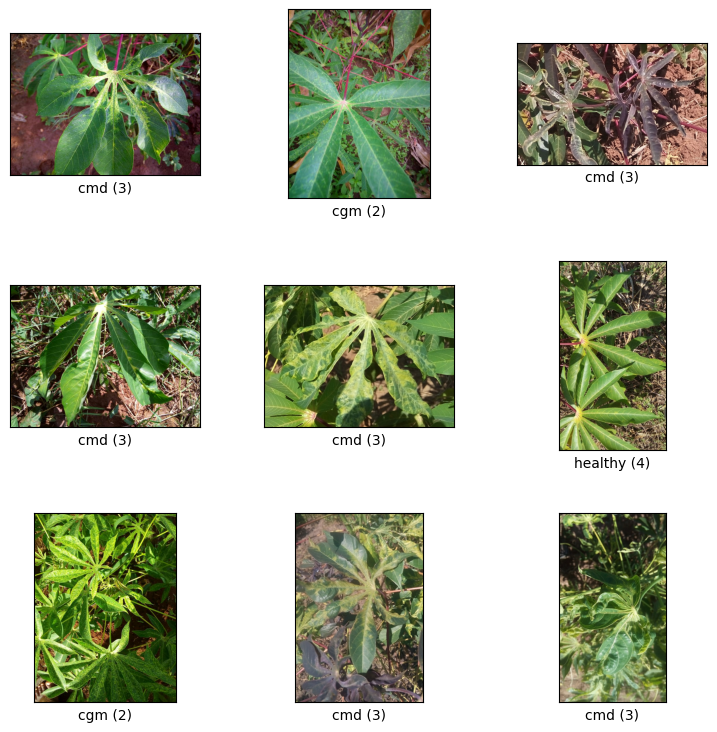

In [16]:
# visualizar alguna imagenes del dataset
fig = tfds.show_examples(ds_train, ds_info)

### **Preprocesamiento: resize de todas las imágenes a 160×160**

In [ ]:
import tensorflow as tf

IMG_SIZE = 160
def resize_image(image, label):
    # tf.image.resize interpola los pixeles a 160x160; NO cambia su rango de
    # valores (siguen ~[0, 255], solo en float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

# Aplicamos el resize a los tres splits: todas las imágenes que usaremos en el
# taller (para Modelo 1 y Modelo 2, y en los tres tamaños de dataset) deben
# quedar en 160x160 para poder alimentarse a las redes y armar batches.
#
# .cache() al final: sin esto, tf.data vuelve a decodificar y hacer resize de
# CADA imagen en CADA época de entrenamiento (y en cada iteración del shuffle
# de buffer completo que viene en la siguiente celda). Con .cache(), ese
# trabajo se hace una sola vez y se guarda en memoria para las siguientes veces
# que se recorra el dataset. Si tu máquina tiene poca RAM, puedes usar
# .cache('ruta/a/archivo') para cachear en disco en vez de memoria.
ds_train = ds_train.map(resize_image, num_parallel_calls=tf.data.AUTOTUNE).cache()
ds_val = ds_val.map(resize_image, num_parallel_calls=tf.data.AUTOTUNE).cache()
ds_test = ds_test.map(resize_image, num_parallel_calls=tf.data.AUTOTUNE).cache()

# Chequeo rápido: todas las imágenes deben salir con la misma forma (160, 160, 3)
for image, label in ds_train.take(1):
    print("Shape:", image.shape, "- dtype:", image.dtype, "- label:", label.numpy())

### **Subconjuntos de entrenamiento (150, 800 y 2500 imágenes)**

In [ ]:
BATCH_SIZE = 32
SEED = 42

# Mezclamos UNA sola vez todo el dataset de entrenamiento (buffer = tamaño
# completo del split, para que el shuffle sea real) y fijamos el orden con
# reshuffle_each_iteration=False. Así, al tomar los subconjuntos con .take(n)
# quedan ANIDADOS. Esto aísla el efecto de "más datos": el subconjunto grande no 
# reemplaza al chico, lo extiende.
train_size = ds_info.splits['train'].num_examples
ds_train_shuffled = ds_train.shuffle(buffer_size=train_size, seed=SEED, reshuffle_each_iteration=False)

ds_train_150  = ds_train_shuffled.take(150)
ds_train_800  = ds_train_shuffled.take(800)
ds_train_2500 = ds_train_shuffled.take(2500)

# Verificación: confirma que cada subconjunto tenga exactamente el tamaño
# esperado (si el split tuviera menos ejemplos de los pedidos, .take(n) se
# quedaría callado con menos imágenes en vez de dar error).
for name, ds in [('150', ds_train_150), ('800', ds_train_800), ('2500', ds_train_2500)]:
    n = tf.data.experimental.cardinality(ds).numpy()
    print(f"Subconjunto de {name} imágenes -> cardinalidad real: {n}")

In [ ]:

# Empacamos cada subconjunto en batches listos para model.fit(). Este shuffle
# es distinto al de arriba: solo reordena los batches dentro de cada época de
# entrenamiento, no cambia qué imágenes quedaron seleccionadas.
def to_batches(ds, n_examples, batch_size=BATCH_SIZE, shuffle=True):
    if shuffle:
        ds = ds.shuffle(n_examples, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_train_150_batched  = to_batches(ds_train_150, 150)
ds_train_800_batched  = to_batches(ds_train_800, 800)
ds_train_2500_batched = to_batches(ds_train_2500, 2500)

# Se usa el MISMO val/test en los 3 experimentos -> se preparan una sola vez
ds_val_batched  = ds_val.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test_batched = ds_test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Modelo 1. CNN desde cero 


  - 3 bloques Conv2D + ReLU + MaxPooling, con 32, 64 y 128 filtros, respectivamente, y kernel 3×3.
  - GlobalAveragePooling2D.
  - Dense(128, activation='relu') + Dropout(0.5).
  - Dense(5, activation='softmax').

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = 160
NUM_CLASSES = 5

def build_model1(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),  # normaliza pixeles de [0, 255] a [0, 1]

        # Bloque 1: Conv2D + ReLU + MaxPooling
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        # Bloque 2: Conv2D + ReLU + MaxPooling
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        # Bloque 3: Conv2D + ReLU + MaxPooling
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='cnn_desde_cero')
    return model

# Usamos una función constructora porque el enunciado pide entrenar este
# mismo modelo desde cero en cada tamaño de dataset (150, 800, 2500 imágenes):
# así cada entrenamiento parte de pesos nuevos, sin arrastrar los del anterior.
model1 = build_model1()
model1.summary()

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # las etiquetas son enteros (as_supervised=True), no one-hot
    metrics=['accuracy']
)

In [13]:
train_size = ds_info.splits['train'].num_examples
print(f"Tamaño del dataset de entrenamiento: {train_size}")

Tamaño del dataset de entrenamiento: 5656


### **Entrenamiento del Modelo 1 (EarlyStopping + los 3 tamaños de dataset)**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 20
PATIENCE = 4

# Si val_loss no mejora durante PATIENCE=4 épocas seguidas, se detiene el
# entrenamiento. restore_best_weights=True es clave: al terminar, el modelo
# queda con los pesos de la época de menor val_loss, no con los de la última
# (que ya venía empeorando cuando se activó el EarlyStopping).
def make_early_stopping():
    return EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)

# Datasets de entrenamiento por tamaño, ya preparados en batches (celda anterior)
train_datasets = {
    150: ds_train_150_batched,
    800: ds_train_800_batched,
    2500: ds_train_2500_batched,
}

models_model1 = {}
histories_model1 = {}

for size, ds_train_batched in train_datasets.items():
    print(f"\n=== Entrenando Modelo 1 (CNN desde cero) con {size} imágenes ===")

    # Modelo NUEVO en cada iteración: build_model1() crea pesos aleatorios
    # frescos. Si reutilizáramos el mismo objeto entre iteraciones, el
    # entrenamiento con 800 y 2500 arrancaría con los pesos ya entrenados
    # del tamaño anterior, y dejaría de ser "desde cero".
    model = build_model1()
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        ds_train_batched,
        validation_data=ds_val_batched,
        epochs=EPOCHS,
        callbacks=[make_early_stopping()],
    )

    # Guardamos modelo e historial por tamaño: los necesitamos después para
    # comparar accuracy/F1 y graficar las curvas de loss/accuracy.
    models_model1[size] = model
    histories_model1[size] = history